langgraph初探，不用真实的llm模型，使用一个简单的模拟器来展示langgraph的基本功能和工作流程。

In [1]:
from langgraph.graph import StateGraph, MessagesState, START, END

def mock_llm(state: MessagesState):
    return {"messages": [{"role": "ai", "content": "hello world"}]}

graph = StateGraph(MessagesState)
graph.add_node(mock_llm)
graph.add_edge(START, "mock_llm")
graph.add_edge("mock_llm", END)
graph = graph.compile()

graph.invoke({"messages": [{"role": "user", "content": "hi!"}]})

{'messages': [HumanMessage(content='hi!', additional_kwargs={}, response_metadata={}, id='aa9134a3-5a2e-4e90-9ab2-c7c19cd4f38a'),
  AIMessage(content='hello world', additional_kwargs={}, response_metadata={}, id='6b9df553-b500-4b67-837a-392fc3b19e80', tool_calls=[], invalid_tool_calls=[])]}

接下来使用真实的LLM来尝试，我们这里不调用本地LLM而是使用云端LLM，通过配置api-key访问，这里以openai schema为例

In [ ]:
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, MessagesState, START, END
from langchain_core.messages import HumanMessage
import os

# 实例化 MiMo 模型
llm = ChatOpenAI(
    model="mimo-v2.5-pro", 
    api_key=os.getenv("MIMO_API_KEY"),  # 替换为你的真实密钥
    base_url="https://token-plan-cn.xiaomimimo.com/v1",  
    temperature=0,  # 温度参数，控制随机性
)

def call_llm(state: MessagesState):
    # 调用 MiMo 模型
    response = llm.invoke(state["messages"])
    return {"messages": [response]} # 这是messagesstate的特殊公功能自动attach，只需要返回本身即可，message列表会自动被attach到state上


# 创建状态图
graph = StateGraph(MessagesState)
graph.add_node("call_llm", call_llm)
graph.add_edge(START, "call_llm")
graph.add_edge("call_llm", END)

# 编译图
compiled_graph = graph.compile()

greet_state = {"messages": [HumanMessage(content="hi! I am studying langgraph.")]}
response = compiled_graph.invoke(greet_state)
response["messages"]

[HumanMessage(content='hi! I am studying langgraph.', additional_kwargs={}, response_metadata={}, id='6a8022a5-c5fb-4276-af6b-54186a4bd5dd'),
 AIMessage(content="Hey there! 👋 That's awesome! LangGraph is a really cool framework for building more complex, stateful applications with LLMs.\n\nI'd love to help you out as you're learning. Are you:\n\n- **Just getting started** with the basics (nodes, edges, state)?\n- **Building something specific** like a chatbot, agent, or multi-step workflow?\n- **Stuck on a concept** or running into issues?\n- **Exploring advanced patterns** like human-in-the-loop, persistence, or branching?\n\nLet me know where you're at or what's on your mind, and we can dive in together! 🚀", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 233, 'prompt_tokens': 259, 'total_tokens': 492, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 97, 'rejected_prediction_tokens

下面我们探究一下langgraph中的状态机制，可以发现返回的内容会进行部分字段的消息更新，也就是合并而不是替换，这种类似于giff的写法容易保留和回溯，同时配合annotate注解和reducer函数，完成消息的自动累加而不是简单的替换

In [1]:
from typing import TypedDict, Annotated
from operator import add
from langgraph.graph import StateGraph, START, END

class TestState(TypedDict):
    messages: Annotated[list, add]
    counter: int
    data: str

def node_only_messages(state: TestState):
    print(f"Node1 收到: {state}")
    return {"messages": ["msg from node1"]}

def node_only_counter(state: TestState):
    print(f"Node2 收到: {state}")
    return {"counter": 1}

def node_only_data(state: TestState):
    print(f"Node3 收到: {state}")
    return {"data": "hello"}

def node_no_return(state: TestState):
    print(f"Node4 收到: {state}")
    return {}  # 返回空字典，不更新任何字段

def node_append_messages(state: TestState):
    print(f"Node5 收到: {state}")
    return {"messages": ["msg from node5, it should be appended to messages, not replace"]}

# 构建图
graph = StateGraph(TestState)
graph.add_node("n1", node_only_messages)
graph.add_node("n2", node_only_counter)
graph.add_node("n3", node_only_data)
graph.add_node("n4", node_no_return)
graph.add_node("n5", node_append_messages)  # 添加一个节点来测试消息的追加

graph.add_edge(START, "n1")
graph.add_edge("n1", "n2")
graph.add_edge("n2", "n3")
graph.add_edge("n3", "n4")
graph.add_edge("n4", "n5")
graph.add_edge("n5", END)

compiled = graph.compile()

# 执行
result = compiled.invoke({"messages": [], "counter": 0, "data": ""})
print("最终状态:", result)


Node1 收到: {'messages': [], 'counter': 0, 'data': ''}
Node2 收到: {'messages': ['msg from node1'], 'counter': 0, 'data': ''}
Node3 收到: {'messages': ['msg from node1'], 'counter': 1, 'data': ''}
Node4 收到: {'messages': ['msg from node1'], 'counter': 1, 'data': 'hello'}
Node5 收到: {'messages': ['msg from node1'], 'counter': 1, 'data': 'hello'}
最终状态: {'messages': ['msg from node1', 'msg from node5, it should be appended to messages, not replace'], 'counter': 1, 'data': 'hello'}


以上展示了langGraph的语法机制，大概可以总结为：
1. langGraph本质是用字典进行状态的封装，尽管写为`class`，但是使用`TypedDict`关键字表示这是一个字典，访问的时候要用`["字段名"]`而不是`.字段名`
1. 一旦你用 `graph = StateGraph(mystate)` 绑定了状态类型，这个状态会成为图中所有节点的统一接口标准;
2. 节点函数不需要返回完整的状态，只需要返回要更新的字段；
3. 配合`Annotate`注解和`reducer`函数，能够完成字段的的自动累加而不是简单的替换，例如`MessagesState`的默认实现
4. 用`HumanMessage`等langGraph包装好的消息体，这可以完成消息的自动处理和转换而不用考虑不同schema之间的转换，并且能够很好的区分system、human、ai、tool等不同的消息

刚刚我们构建的一些操作，本质是链式的, 但是这些功能理论上langchain等链式架构也可以轻易完成，接下来探究一下langGraph真正的核心机制，状态图，
首先可以通过代码来看到图的结构, 这里我们使用 `get_graph()`函数，注意，一定是`compile`之后的图

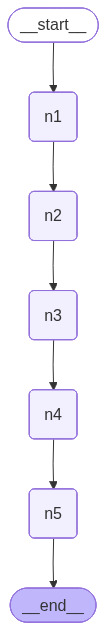

In [4]:
from IPython.display import Image

# 直接在 Notebook 中显示图片
Image(compiled.get_graph().draw_mermaid_png())

可以看到整个工作流是线性的，但是如果要构建一个良好的agent，需要进行的处理绝对不是简单的线性的，需要根据每一步执行的结果进行调整下一步要执行的操作，一个很简单的例子，如果我们想要LLM输出一个结构化的Json并给出了schema，但是LLM的输出总是没有那么稳定，我们需要一次后检判断LLM的输出是否非法，如果非法需要让他重新生成，并且告诉LLM为什么错了，这就是一个标准的回溯逻辑，我们必须引入langGraph的一个核心成员，条件边，也就是`conditionnal_edge`, 通过

In [ ]:
from typing import TypedDict, Annotated
from operator import add
from langgraph.graph import StateGraph, START, END

class TestState(TypedDict):
    messages: Annotated[list, add]
    counter: int
    data: str

def node_only_messages(state: TestState):
    print(f"Node1 收到: {state}")
    return {"messages": ["msg from node1"]}

def node_only_counter(state: TestState):
    print(f"Node2 收到: {state}")
    return {"counter": 1}

def node_only_data(state: TestState):
    print(f"Node3 收到: {state}")
    return {"data": "hello"}

def node_no_return(state: TestState):
    print(f"Node4 收到: {state}")
    return {}  # 返回空字典，不更新任何字段

def node_append_messages(state: TestState):
    print(f"Node5 收到: {state}")
    return {"messages": ["msg from node5, it should be appended to messages, not replace"]}

# 构建图
graph = StateGraph(TestState)
graph.add_node("n1", node_only_messages)
graph.add_node("n2", node_only_counter)
graph.add_node("n3", node_only_data)
graph.add_node("n4", node_no_return)
graph.add_node("n5", node_append_messages)  # 添加一个节点来测试消息的追加

graph.add_edge(START, "n1")
graph.add_edge("n1", "n2")
graph.add_edge("n2", "n3")
graph.add_edge("n3", "n4")
graph.add_edge("n4", "n5")
graph.add_edge("n5", END)

compiled = graph.compile()

# 执行
result = compiled.invoke({"messages": [], "counter": 0, "data": ""})
print("最终状态:", result)
